In [2]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import scanpy as sc
import pandas as pd
import anndata as ad
from tqdm import tqdm
from scipy import sparse
import scipy.sparse as sp
import gc
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')
import sklearn

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/low_dimensional_rep
scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [3]:
import torch 
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cpu


In [1]:
import sys
sys.path.append('../../utils')
from functions import * 

In [5]:
from importlib import reload
import sys

# Replace 'PATH_TO_REPOSITORY' with the actual path to the repository containing load_cluster_data.py
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-lda/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [7]:
# Now you can import the module
from load_cluster_data import load_cluster_data
import splicing_PCA_utils
from splicing_PCA_utils import make_Y

import nuclear_norm_PCA as knuckle # knuckle: Konvex NUClear norm Konstrained Linear Embedding
import splicing_PCA_utils 

In [8]:
# this folder contains input data for each tissue cell type sample
#input_files_folder = '/gpfs/commons/scratch/kisaev/ss_tabulamuris_test/Leaflet/Brain/'

input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/parse-pbmc-leafcutter/Leaflet/BBmixture_PBMC_input_morestringent/'

In [9]:
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
    input_folder = input_files_folder) 

Reading in data from folder ...
/gpfs/commons/scratch/kisaev/ss_tabulamuris_test/Leaflet/Brain/
Finished reading in data from folder ...
['Brain_Myeloid_microglial_cell' 'Brain_Non-Myeloid_astrocyte'
 'Brain_Non-Myeloid_brain_pericyte' 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_neuron' 'Brain_Non-Myeloid_endothelial_cell'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Myeloid_macrophage' 'Brain_Non-Myeloid_Bergmann_glial_cell']
7856
7856
49190
49190
The number of junctions in the data is:  49190
The number of cells in the data is:  7856
The number of cell types in the data is:  9


In [10]:
# still do preprocessing in scipy
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)

junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [18]:
junc_counts.shape

(7856, 49190)

also printing original indices of junctions we are keeping


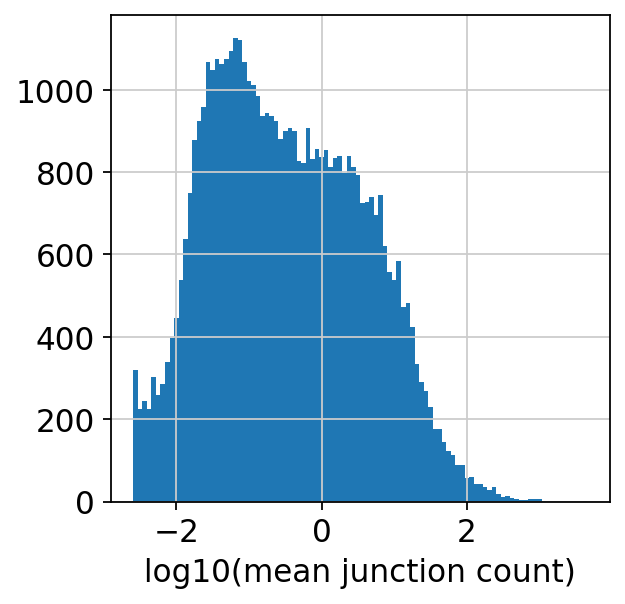

In [12]:
junc_counts_sub, cluster_counts_sub, junc_keep = splicing_PCA_utils.filter_junctions(
    junc_counts, cluster_counts, plot = True)

In [20]:
junc_counts_sub.shape
cluster_counts_sub.shape

(7856, 47974)

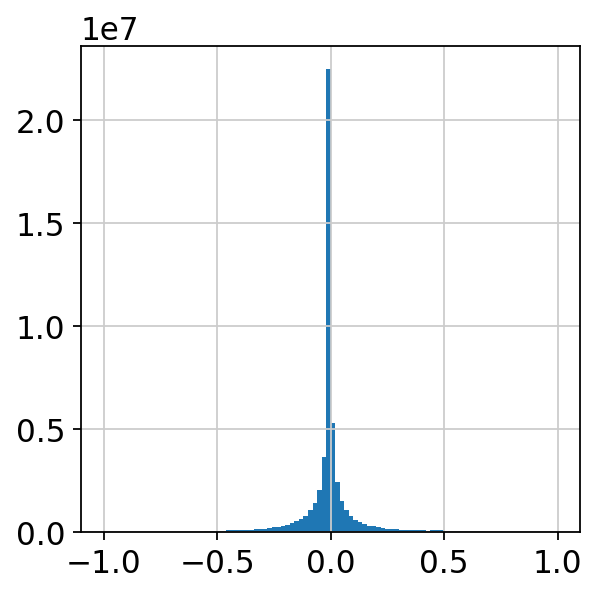

In [21]:
# set up data for nuc norm PCA
Y_data, w = splicing_PCA_utils.make_Y(
    junc_counts_sub, cluster_counts_sub, float_type)

# np.mean(Y_data * Y_data) * psi.shape[0] * psi.shape[1]
Y = torch.tensor(Y_data, **float_type)
W = torch.tensor(w.data, **float_type)

_ = plt.hist(Y_data, 100) # centered so the distribution peaks at 0 and is in [-1,1]

In [22]:
Y_train, W_train, indices_train, Y_test, W_test, indices_test = splicing_PCA_utils.train_test(
    Y_data, w, float_type)

In [25]:
rmseTol = 5e-5
its=1

rs, testErrors, trainErrors, nuc_norms, final_svd, step_times = knuckle.constraint_search(
    indices_train, 
    Y_train, 
    W_train, 
    size = junc_counts_sub.shape,
    indices_test = indices_test, 
    Y_test = Y_test, 
    W_test = W_test, 
    rmseTol = rmseTol, 
    end = "\n",
    inner_verbose = True,
    power_iteration_controller = (30,1.),
    its = its,  
    **float_type)


CV	Bound	RMSE	TestRMSE
It	RMSE	Step	DeltaRMSE
CV	1e+03	0.132	0.132
It	RMSE	Step	DeltaRMSE
CV	1.5e+03	0.131	0.132
It	RMSE	Step	DeltaRMSE
CV	2.25e+03	0.131	0.131
It	RMSE	Step	DeltaRMSE
CV	3.38e+03	0.131	0.131
It	RMSE	Step	DeltaRMSE
CV	5.06e+03	0.13	0.131
It	RMSE	Step	DeltaRMSE
CV	7.59e+03	0.13	0.131
It	RMSE	Step	DeltaRMSE
CV	1.14e+04	0.13	0.131
It	RMSE	Step	DeltaRMSE
CV	1.71e+04	0.13	0.13
It	RMSE	Step	DeltaRMSE
CV	2.56e+04	0.129	0.13
It	RMSE	Step	DeltaRMSE
CV	3.84e+04	0.129	0.13
It	RMSE	Step	DeltaRMSE
CV	5.77e+04	0.129	0.13
It	RMSE	Step	DeltaRMSE
CV	8.65e+04	0.129	0.13
It	RMSE	Step	DeltaRMSE
CV	1.3e+05	0.129	0.13f
It	RMSE	Step	DeltaRMSE
CV	1.95e+05	0.128	0.13
It	RMSE	Step	DeltaRMSE
CV	2.92e+05	0.128	0.13
It	RMSE	Step	DeltaRMSE


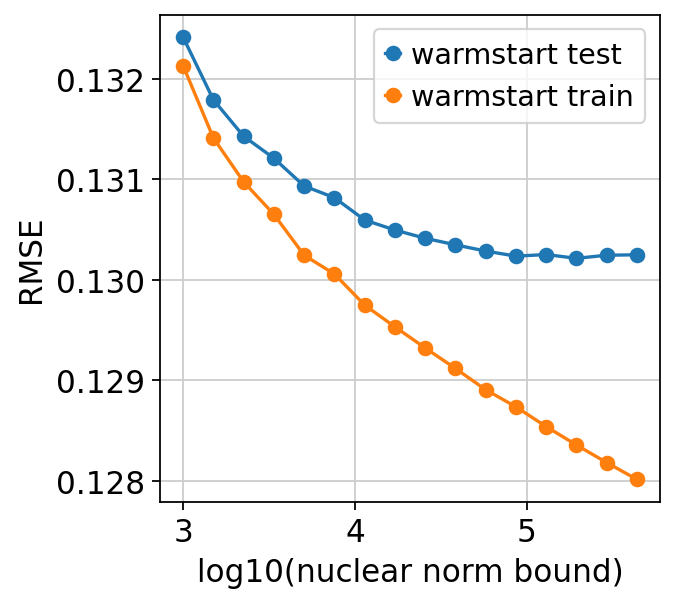

In [26]:
plt.plot(np.log10(rs), testErrors,"-o", label = "warmstart test")
plt.plot(np.log10(rs), trainErrors, "-o", label = "warmstart train")
plt.ylabel("RMSE")
plt.xlabel("log10(nuclear norm bound)")
plt.legend()

tensor(1167.8256)

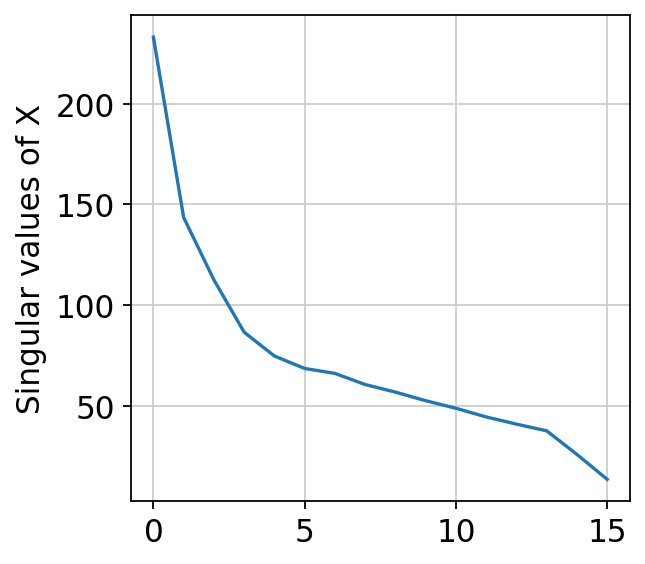

In [27]:
plt.plot(final_svd.S)
plt.ylabel("Singular values of X") 
final_svd.S.sum()

Text(0, 0.5, 'log10(Nuc norm obtained)')

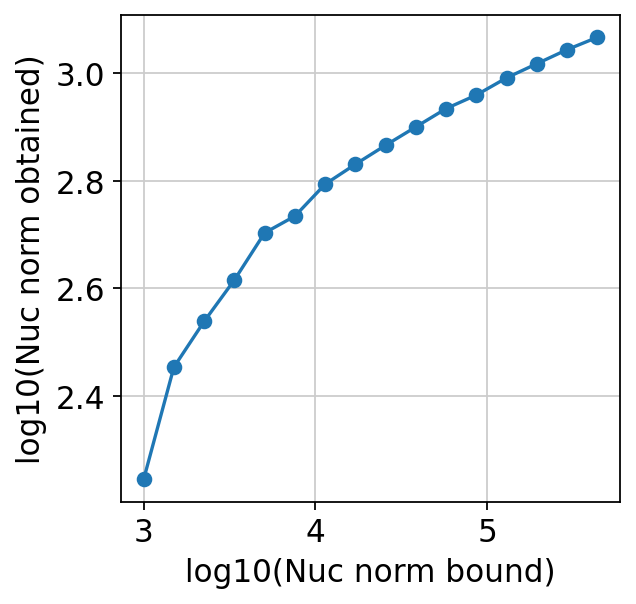

In [28]:
# solution is on the boundary up to about ~1e4, then is inside. 
plt.plot(np.log10(rs), np.log10(nuc_norms), "-o", label = "warmstart")
plt.xlabel("log10(Nuc norm bound)")
plt.ylabel("log10(Nuc norm obtained)")

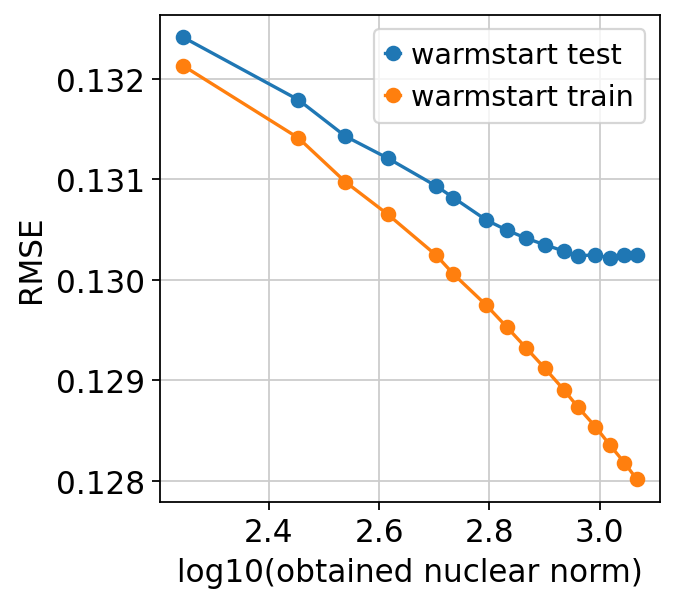

In [29]:
plt.plot(np.log10(nuc_norms), testErrors,"-o", label = "warmstart test")
plt.plot(np.log10(nuc_norms), trainErrors, "-o", label = "warmstart train")
plt.ylabel("RMSE")
plt.xlabel("log10(obtained nuclear norm)")
plt.legend()

In [30]:
r_best = rs[np.argmin(testErrors)]
r_best

194619.5068359375

In [31]:
r_best = 1.0e6 # minimal gains after this

In [32]:
Y,W,indices = splicing_PCA_utils.to_torch(Y_data, w, **float_type)

In [33]:
reload(knuckle)
rs, _, trainErrors_all, nuc_norms_all, final_svd_all, step_times = knuckle.constraint_search(
    indices, 
    Y, 
    W, 
    size = junc_counts_sub.shape,
    rmseTol = rmseTol, 
    its = its,  
    max_r = r_best, 
    end = "\n",
    **float_type)


CV	Bound	RMSE	TestRMSE
CV	1e+03	0.132	nan
CV	1.5e+03	0.131	nan
CV	2.25e+03	0.131	nan
CV	3.38e+03	0.131	nan
CV	5.06e+03	0.13	nan
CV	7.59e+03	0.13	nan
CV	1.14e+04	0.13	nan
CV	1.71e+04	0.13	nan
CV	2.56e+04	0.129	nan
CV	3.84e+04	0.129	nan
CV	5.77e+04	0.129	nan
CV	8.65e+04	0.129	nan
CV	1.3e+05	0.129	nan
CV	1.95e+05	0.129	nan
CV	2.92e+05	0.128	nan
CV	4.38e+05	0.128	nan
CV	6.57e+05	0.128	nan
CV	9.85e+05	0.128	nan


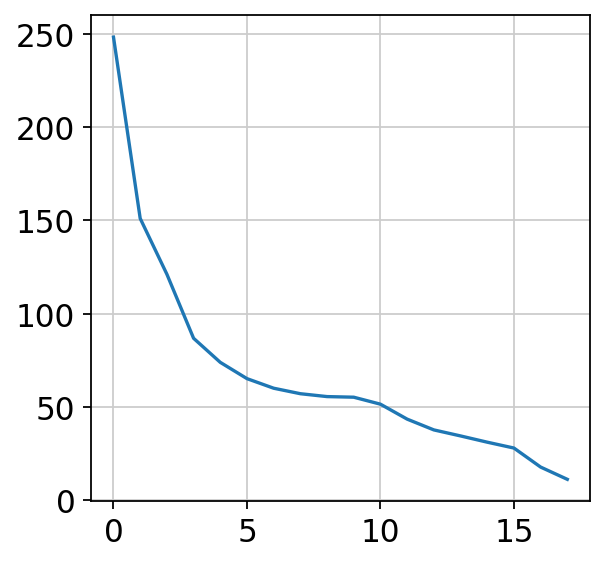

In [34]:
plt.plot(final_svd_all.S)

<Axes: xlabel='PC1', ylabel='PC2'>

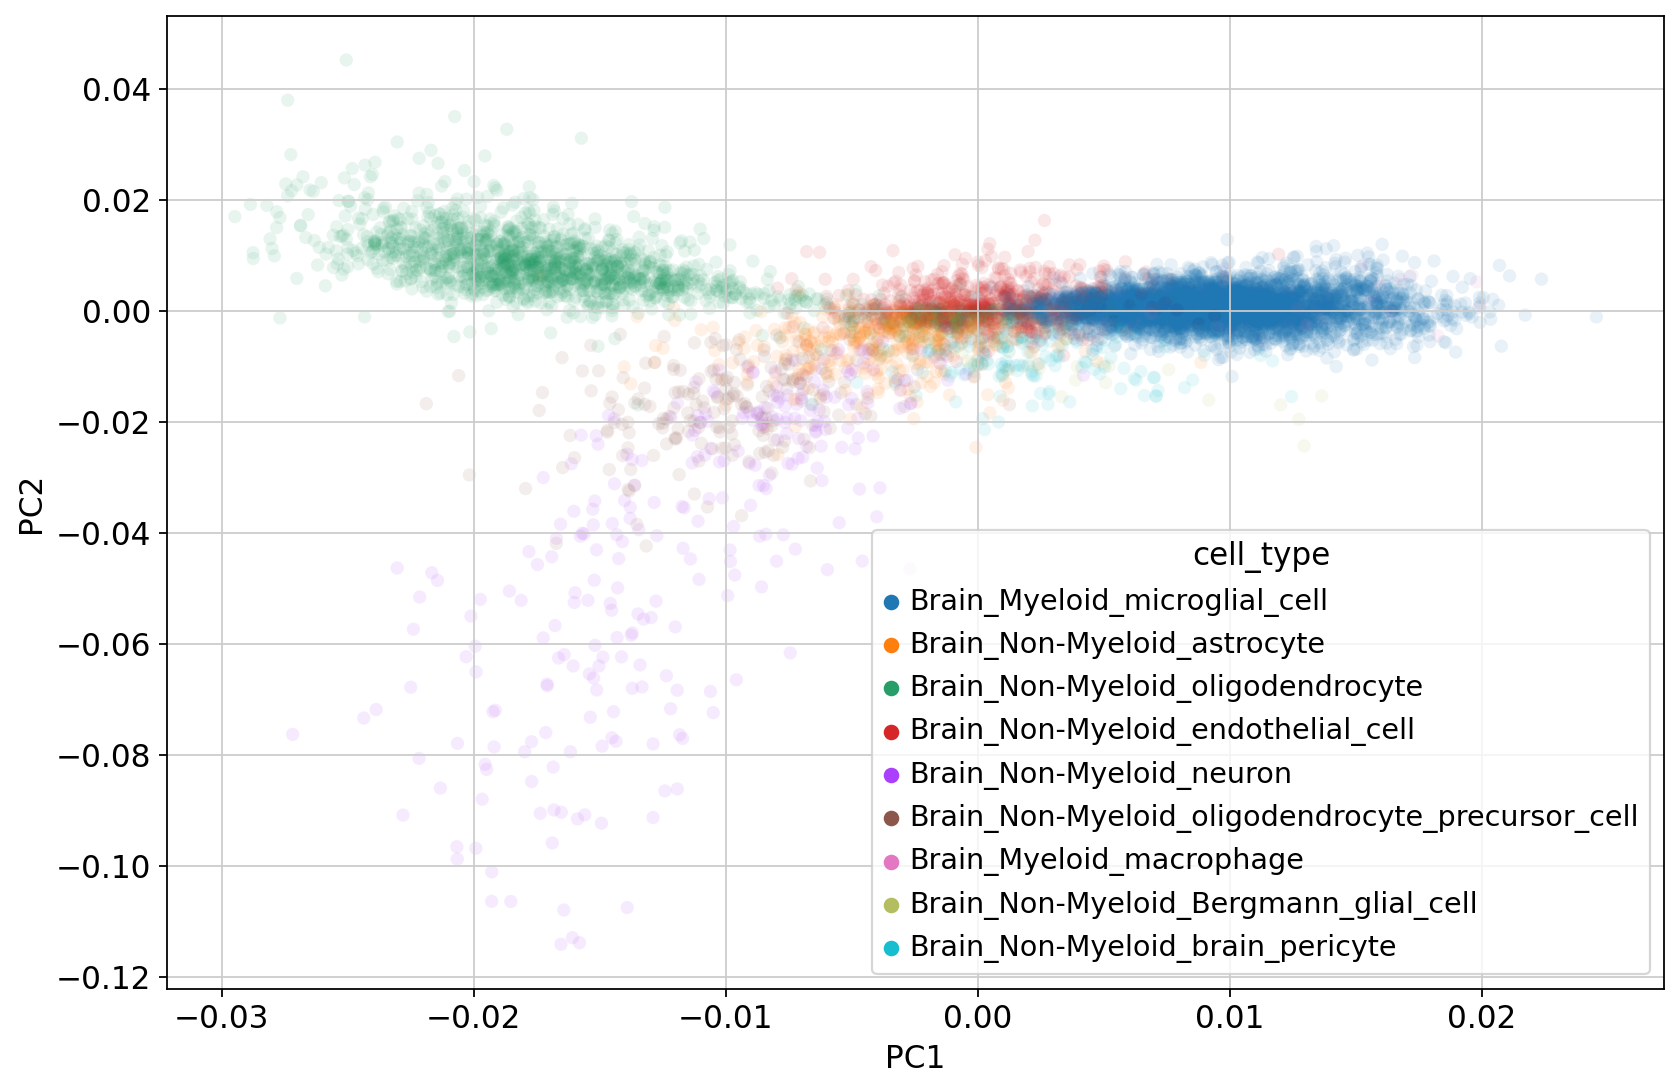

In [35]:
import pandas as pd 
import seaborn as sns
# U_mat.T @ U_mat

PC_embed_df = pd.DataFrame({"PC1" : final_svd_all.U[:,0], "PC2" : final_svd_all.U[:,1]})
PC_embed_df["cell_type"] = cell_ids_conversion["cell_type"].to_numpy()
#p9.ggplot(X_embed_df, p9.aes(x = "x", y="y", color = "cell_type")) + p9.geom_point()

#plt.figure(figsize=[8,6]) # for pdf
plt.figure(figsize=[12,8])
sns.scatterplot(x = "PC1",y = "PC2", hue="cell_type", data= PC_embed_df, edgecolor = 'none', alpha = 0.1)


(0.0, 100.0)

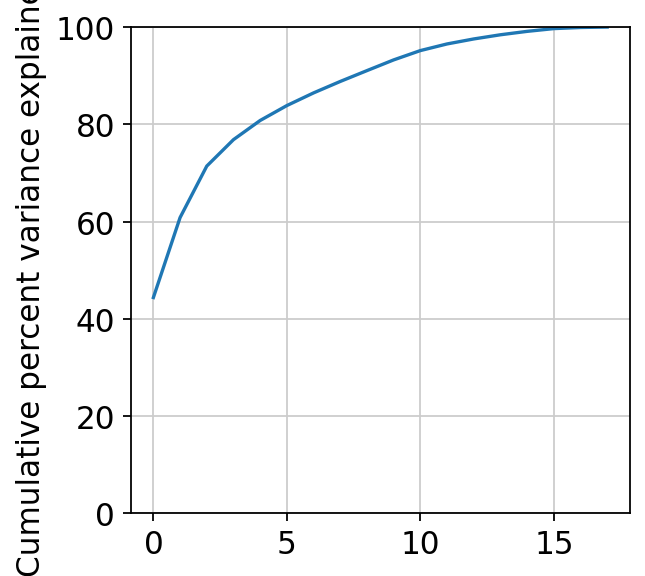

In [36]:
pve = final_svd_all.S**2
pve /= pve.sum()
pve = pve.cumsum(0) * 100
plt.plot(pve)
plt.ylabel("Cumulative percent variance explained")
plt.ylim(0,100)

In [43]:
def tsne_plot(E, cell_ids_conversion):

    PCs_embedded = sklearn.manifold.TSNE(
        n_components=2, 
        learning_rate='auto',
        init='random', 
        perplexity=30).fit_transform(E.numpy()) # scale by SVs?

    PC_embed_df = pd.DataFrame(PCs_embedded, columns = ["x","y"])
    PC_embed_df["cell_type"] = cell_ids_conversion["cell_type"].to_numpy()

    plt.figure(figsize=[12,8])
    sns.scatterplot(x = "x",y = "y", hue="cell_type", data= PC_embed_df, edgecolor = 'none', alpha = 0.1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel("tSNE 1")
    plt.ylabel("tSNE 2")
    ax = plt.gca()
    ax.set_xticks([])
    ax.set_yticks([])

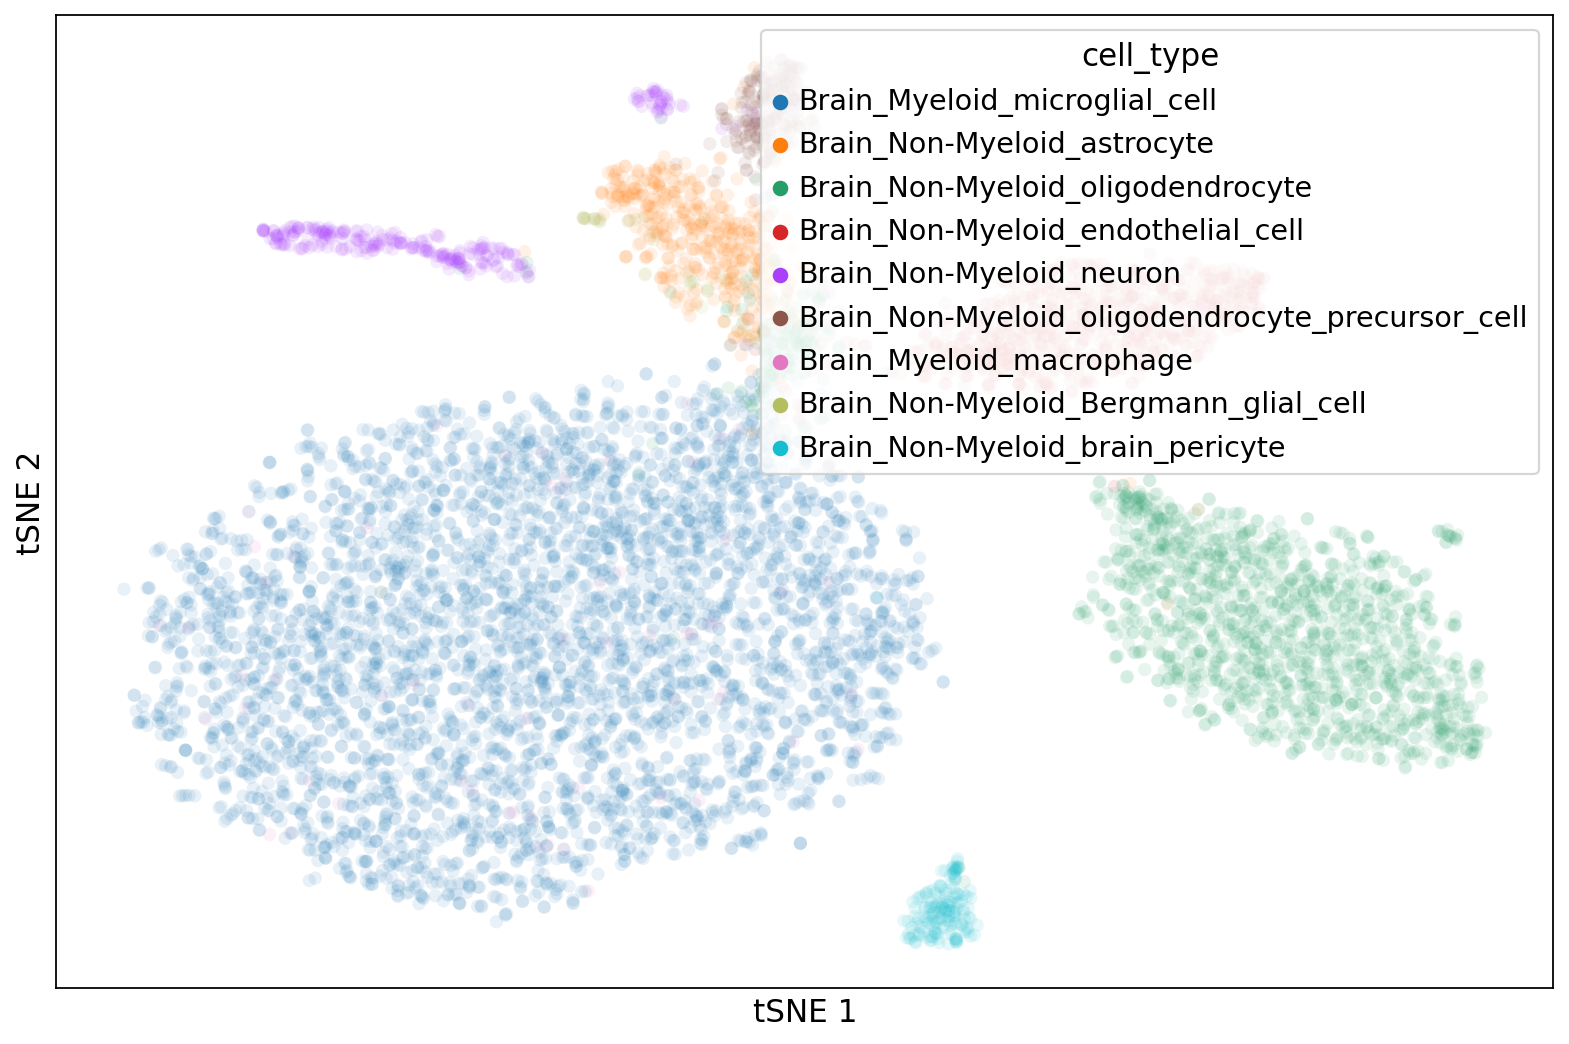

In [42]:
E = final_svd_all.U * final_svd_all.S

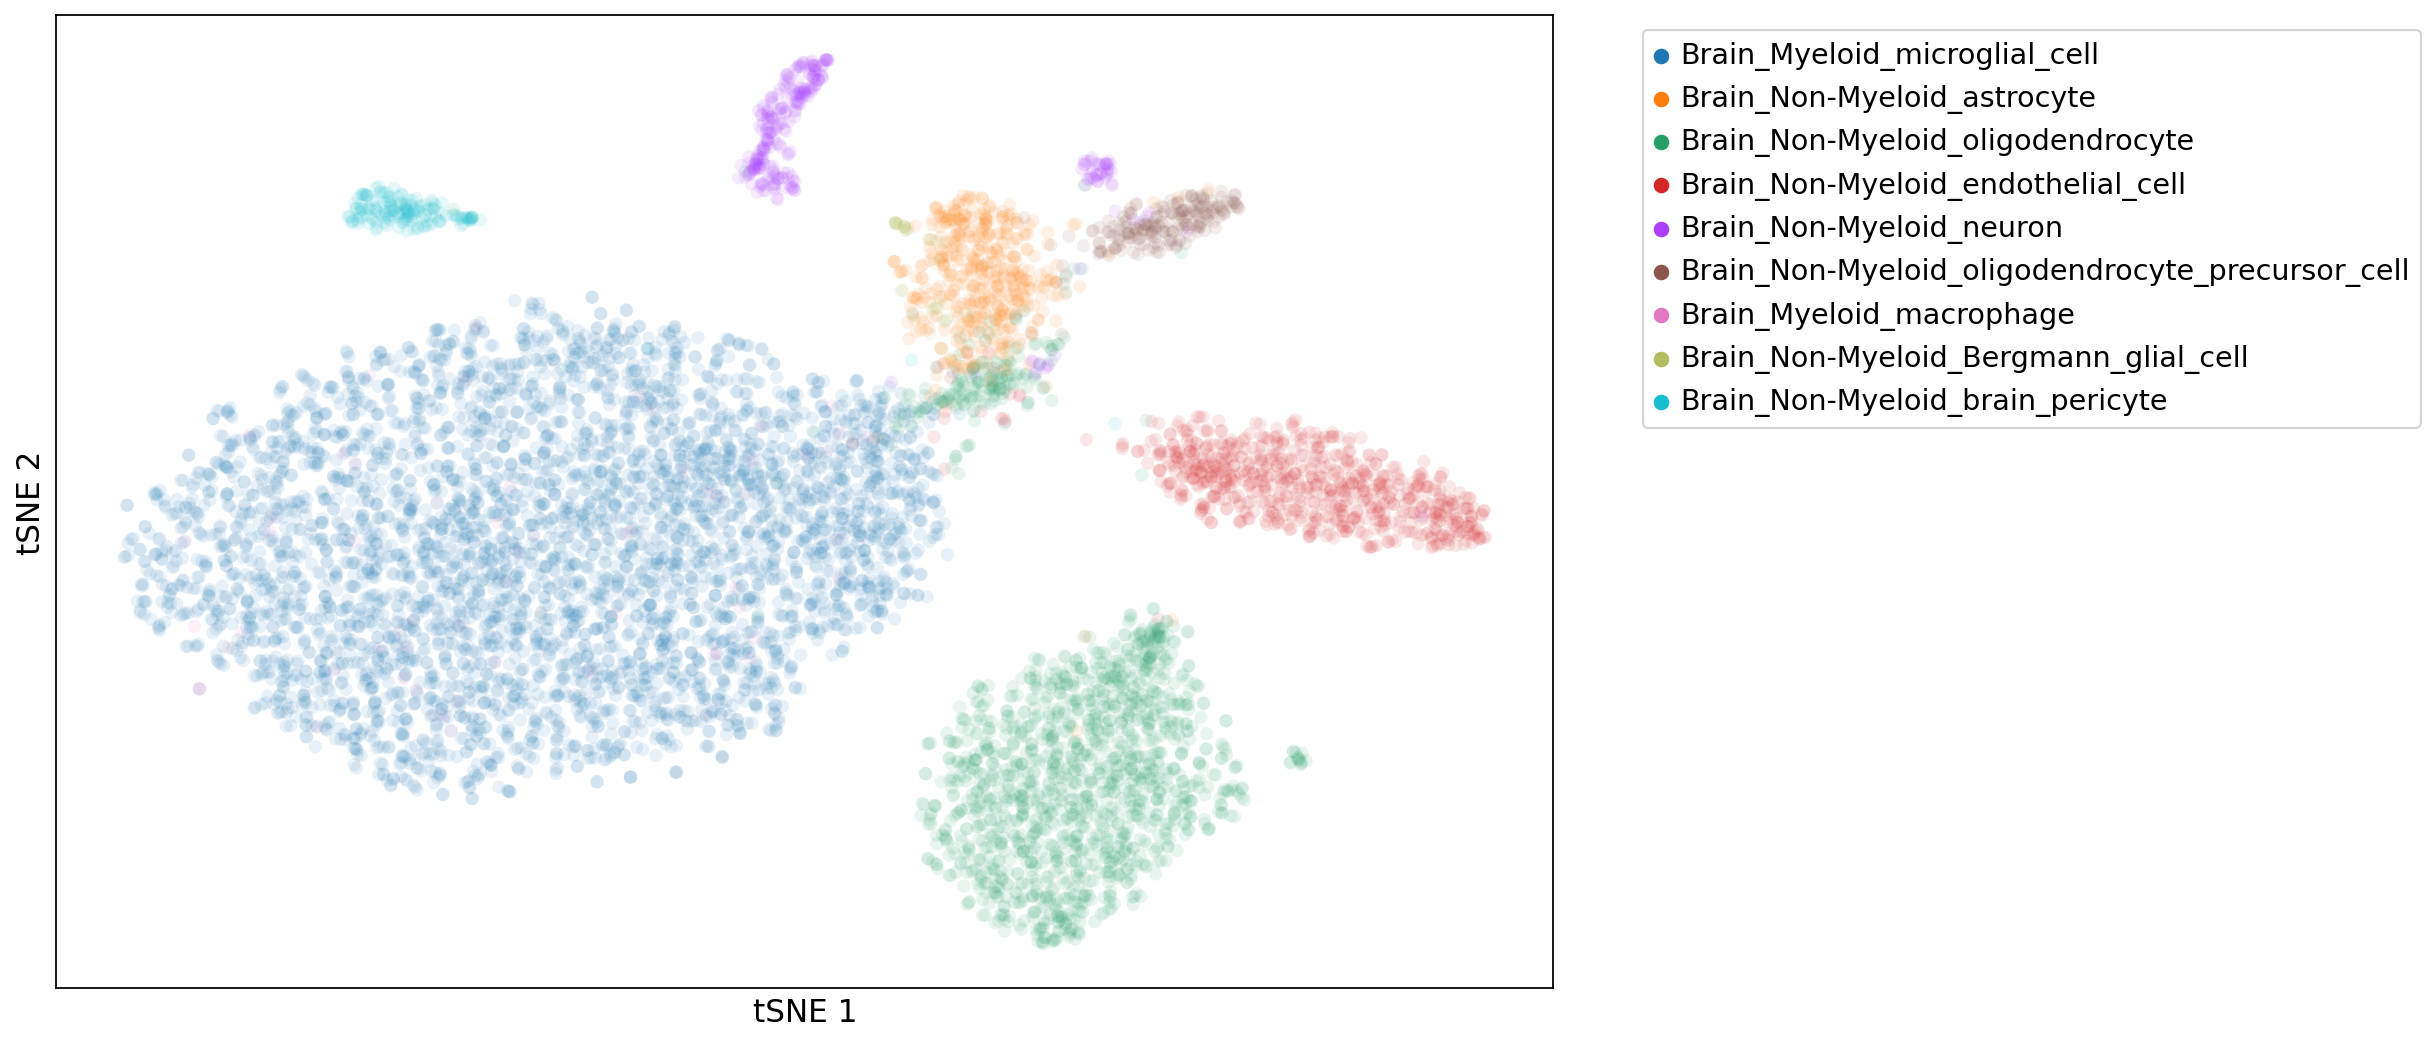

In [44]:
tsne_plot(E, cell_ids_conversion)